In [12]:
from sklearn.semi_supervised import LabelSpreading

from sklearn.semi_supervised import LabelPropagation
from scipy.sparse import issparse, vstack

from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("../data/processed/diabetes_clean_2.csv")
df.shape

(70422, 30)

In [3]:

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

numeric_features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

categorical_features = [
    'race', 'gender', 'age',
    'metformin', 'repaglinide', 'nateglinide', 'glimepiride',
    'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone',
    'insulin', 'glyburide-metformin', 'change', 'diabetesMed',
    'diag_1_grp', 'diag_2_grp', 'diag_3_grp',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id'
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train).toarray()
X_test_processed = preprocessor.transform(X_test).toarray()

print(X_train_processed.shape)
print(X_test_processed.shape)

(56337, 143)
(14085, 143)


In [4]:
fractions = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

### LabelSpreading

In [15]:

results_ls = []

for frac in fractions:
    print(f"\nRunning LabelSpreading with {int(frac*100)}% labeled...")

    all_idx = np.arange(len(y_train))

    labeled_idx, unlabeled_idx = train_test_split(
        all_idx,
        train_size=frac,
        random_state=42,
        stratify=y_train
    )

    y_train_semi = y_train.to_numpy().copy()
    y_train_semi[unlabeled_idx] = -1

    model = LabelSpreading(kernel="knn", n_neighbors=7, max_iter=1000)
    model.fit(X_train_processed, y_train_semi)

    y_pred = model.predict(X_test_processed)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)

    results_ls.append([frac, acc, prec, rec, f1])

results_ls = pd.DataFrame(
    results_ls,
    columns=["fraction", "accuracy", "precision", "recall", "f1"]
)

results_ls


Running LabelSpreading with 10% labeled...


c:\Users\samir\anaconda3\envs\dv2607\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


Accuracy: 0.903940362087327
Precision: 0.14285714285714285
Recall: 0.015103338632750398
F1: 0.027318475916606758

Running LabelSpreading with 20% labeled...
Accuracy: 0.9071352502662406
Precision: 0.1794871794871795
Recall: 0.011128775834658187
F1: 0.020958083832335328

Running LabelSpreading with 30% labeled...
Accuracy: 0.9093361732339368
Precision: 0.2682926829268293
Recall: 0.008744038155802861
F1: 0.016936104695919937

Running LabelSpreading with 40% labeled...
Accuracy: 0.9100461483848066
Precision: 0.3448275862068966
Recall: 0.00794912559618442
F1: 0.01554001554001554

Running LabelSpreading with 50% labeled...
Accuracy: 0.9096911608093716
Precision: 0.20833333333333334
Recall: 0.00397456279809221
F1: 0.0078003120124804995

Running LabelSpreading with 60% labeled...
Accuracy: 0.9099751508697196
Precision: 0.2727272727272727
Recall: 0.0047694753577106515
F1: 0.009375

Running LabelSpreading with 70% labeled...
Accuracy: 0.9094071707490238
Precision: 0.09090909090909091
Recall: 0.

,fraction,accuracy,precision,recall,f1
0,0.1,0.903940,0.142857,0.015103,0.027318
1,0.2,0.907135,0.179487,0.011129,0.020958
2,0.3,0.909336,0.268293,0.008744,0.016936
3,0.4,0.910046,0.344828,0.007949,0.015540
4,0.5,0.909691,0.208333,0.003975,0.007800
5,0.6,0.909975,0.272727,0.004769,0.009375
6,0.7,0.909407,0.090909,0.001590,0.003125
7,0.8,0.909691,0.111111,0.001590,0.003135
8,0.9,0.909620,0.142857,0.002385,0.004691


### LabelPropagation

In [10]:
results_lp = []

for frac in fractions:
    print(f"\nRunning LabelPropagation with {int(frac*100)}% labeled...")

    # indices
    all_idx = np.arange(len(y_train))

    # stratified labeled/unlabeled split
    labeled_idx, unlabeled_idx = train_test_split(
        all_idx,
        train_size=frac,
        random_state=42,
        stratify=y_train
    )

    # create semi-supervised labels
    y_train_semi = y_train.to_numpy().copy()
    y_train_semi[unlabeled_idx] = -1

    # ----- handle imbalance in labeled subset only -----
    y_labeled = y_train.iloc[labeled_idx].to_numpy()

    class_0_idx = labeled_idx[y_labeled == 0]
    class_1_idx = labeled_idx[y_labeled == 1]

    # identify minority / majority
    if len(class_0_idx) > len(class_1_idx):
        majority_idx = class_0_idx
        minority_idx = class_1_idx
    else:
        majority_idx = class_1_idx
        minority_idx = class_0_idx

    # oversample minority labeled samples
    n_to_add = len(majority_idx) - len(minority_idx)

    if n_to_add > 0:
        extra_minority_idx = np.random.RandomState(42).choice(
            minority_idx,
            size=n_to_add,
            replace=True
        )

        # build augmented training set
        if issparse(X_train_processed):
            X_extra = X_train_processed[extra_minority_idx]
            X_train_aug = vstack([X_train_processed, X_extra])
        else:
            X_extra = X_train_processed[extra_minority_idx]
            X_train_aug = np.vstack([X_train_processed, X_extra])

        y_extra = y_train.iloc[extra_minority_idx].to_numpy()
        y_train_aug = np.concatenate([y_train_semi, y_extra])

    else:
        X_train_aug = X_train_processed
        y_train_aug = y_train_semi

    # model
    model = LabelPropagation(kernel="knn", n_neighbors=7, max_iter=1000)

    model.fit(X_train_aug, y_train_aug)

    # predict
    y_pred = model.predict(X_test_processed)

    # evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)

    results_lp.append([frac, acc, prec, rec, f1])

results_lp_df = pd.DataFrame(
    results_lp,
    columns=["fraction", "accuracy", "precision", "recall", "f1"]
)

results_lp_df


Running LabelPropagation with 10% labeled...


c:\Users\samir\anaconda3\envs\dv2607\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(
c:\Users\samir\anaconda3\envs\dv2607\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


Accuracy: 0.8724884629037983
Precision: 0.12324929971988796
Recall: 0.06995230524642289
F1: 0.08924949290060852

Running LabelPropagation with 20% labeled...
Accuracy: 0.8442314518991836
Precision: 0.12135922330097088
Recall: 0.1192368839427663
F1: 0.12028869286287089

Running LabelPropagation with 30% labeled...
Accuracy: 0.8178913738019169
Precision: 0.11850554582603619
Recall: 0.16136724960254373
F1: 0.13665432514304948

Running LabelPropagation with 40% labeled...
Accuracy: 0.792332268370607
Precision: 0.1178358551123338
Recall: 0.20429252782193957
F1: 0.14946205292236114

Running LabelPropagation with 50% labeled...
Accuracy: 0.7710330138445154
Precision: 0.11536957371920219
Recall: 0.23449920508744038
F1: 0.15465268676277852

Running LabelPropagation with 60% labeled...
Accuracy: 0.751863684771033
Precision: 0.11444329541537401
Recall: 0.26391096979332274
F1: 0.15965376292377975

Running LabelPropagation with 70% labeled...
Accuracy: 0.7334753283635073
Precision: 0.11218147917961

,fraction,accuracy,precision,recall,f1
0,0.1,0.872488,0.123249,0.069952,0.089249
1,0.2,0.844231,0.121359,0.119237,0.120289
2,0.3,0.817891,0.118506,0.161367,0.136654
3,0.4,0.792332,0.117836,0.204293,0.149462
4,0.5,0.771033,0.115370,0.234499,0.154653
5,0.6,0.751864,0.114443,0.263911,0.159654
6,0.7,0.733475,0.112181,0.286963,0.161305
7,0.8,0.717785,0.107937,0.297297,0.158374
8,0.9,0.703230,0.108940,0.323529,0.162996


### SelfTrainingClassifier(LogisticRegression)

In [13]:

results_st = []

for frac in fractions:
    print(f"\nRunning SelfTraining + LogisticRegression with {int(frac*100)}% labeled...")

    all_idx = np.arange(len(y_train))

    labeled_idx, unlabeled_idx = train_test_split(
        all_idx,
        train_size=frac,
        random_state=42,
        stratify=y_train
    )

    y_train_semi = y_train.to_numpy().copy()
    y_train_semi[unlabeled_idx] = -1

    base_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    model = SelfTrainingClassifier(
        estimator=base_model,
        threshold=0.8,
        verbose=False
    )

    model.fit(X_train_processed, y_train_semi)

    y_pred = model.predict(X_test_processed)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)

    results_st.append([frac, acc, prec, rec, f1])

results_st_df = pd.DataFrame(
    results_st,
    columns=["fraction", "accuracy", "precision", "recall", "f1"]
)

results_st_df


Running SelfTraining + LogisticRegression with 10% labeled...
Accuracy: 0.7196308129215477
Precision: 0.13781965006729474
Recall: 0.4069952305246423
F1: 0.20591192439171527

Running SelfTraining + LogisticRegression with 20% labeled...
Accuracy: 0.7399361022364217
Precision: 0.15114592399187698
Recall: 0.41414944356120825
F1: 0.22146652497343253

Running SelfTraining + LogisticRegression with 30% labeled...
Accuracy: 0.7320553780617678
Precision: 0.14860335195530727
Recall: 0.42289348171701113
F1: 0.21992558908639934

Running SelfTraining + LogisticRegression with 40% labeled...
Accuracy: 0.7592474263400781
Precision: 0.15806348188521963
Recall: 0.3918918918918919
F1: 0.22526844870916152

Running SelfTraining + LogisticRegression with 50% labeled...
Accuracy: 0.7600993965211218
Precision: 0.1599871753767233
Recall: 0.39666136724960255
F1: 0.2280100525474069

Running SelfTraining + LogisticRegression with 60% labeled...
Accuracy: 0.7348952786652467
Precision: 0.15185601799775028
Recall

,fraction,accuracy,precision,recall,f1
0,0.1,0.719631,0.137820,0.406995,0.205912
1,0.2,0.739936,0.151146,0.414149,0.221467
2,0.3,0.732055,0.148603,0.422893,0.219926
3,0.4,0.759247,0.158063,0.391892,0.225268
4,0.5,0.760099,0.159987,0.396661,0.228010
5,0.6,0.734895,0.151856,0.429253,0.224346
6,0.7,0.715300,0.146091,0.451510,0.220754
7,0.8,0.691161,0.140799,0.481717,0.217907
8,0.9,0.675186,0.138119,0.503180,0.216744


In [16]:
comparison_df = pd.DataFrame({
    "fraction": results_ls["fraction"],                  # LabelSpreading
    "LS_f1": results_ls["f1"],
    "LP_f1": results_lp_df["f1"],
    "ST_f1": results_st_df["f1"],
    "LS_recall": results_ls["recall"],
    "LP_recall": results_lp_df["recall"],
    "ST_recall": results_st_df["recall"],
})

comparison_df

,fraction,LS_f1,LP_f1,ST_f1,LS_recall,LP_recall,ST_recall
0,0.1,0.027318,0.089249,0.205912,0.015103,0.069952,0.406995
1,0.2,0.020958,0.120289,0.221467,0.011129,0.119237,0.414149
2,0.3,0.016936,0.136654,0.219926,0.008744,0.161367,0.422893
3,0.4,0.015540,0.149462,0.225268,0.007949,0.204293,0.391892
4,0.5,0.007800,0.154653,0.228010,0.003975,0.234499,0.396661
5,0.6,0.009375,0.159654,0.224346,0.004769,0.263911,0.429253
6,0.7,0.003125,0.161305,0.220754,0.001590,0.286963,0.451510
7,0.8,0.003135,0.158374,0.217907,0.001590,0.297297,0.481717
8,0.9,0.004691,0.162996,0.216744,0.002385,0.323529,0.503180


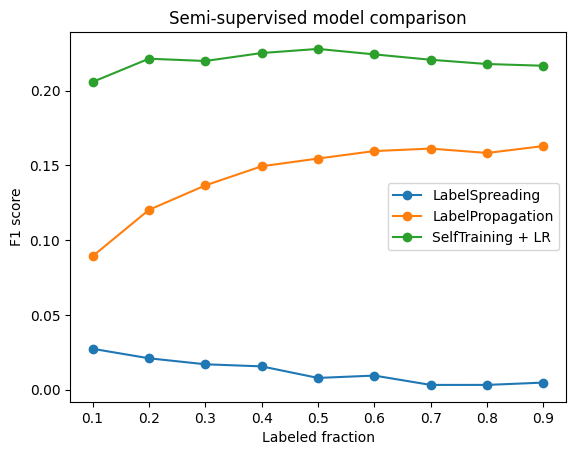

In [17]:
import matplotlib.pyplot as plt

plt.plot(comparison_df["fraction"], comparison_df["LS_f1"], marker="o", label="LabelSpreading")
plt.plot(comparison_df["fraction"], comparison_df["LP_f1"], marker="o", label="LabelPropagation")
plt.plot(comparison_df["fraction"], comparison_df["ST_f1"], marker="o", label="SelfTraining + LR")

plt.xlabel("Labeled fraction")
plt.ylabel("F1 score")
plt.title("Semi-supervised model comparison")
plt.legend()
plt.show()

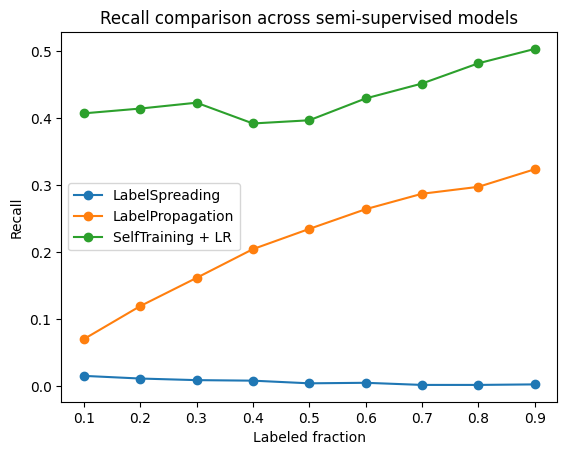

In [18]:
plt.plot(comparison_df["fraction"], comparison_df["LS_recall"], marker="o", label="LabelSpreading")
plt.plot(comparison_df["fraction"], comparison_df["LP_recall"], marker="o", label="LabelPropagation")
plt.plot(comparison_df["fraction"], comparison_df["ST_recall"], marker="o", label="SelfTraining + LR")

plt.xlabel("Labeled fraction")
plt.ylabel("Recall")
plt.title("Recall comparison across semi-supervised models")
plt.legend()
plt.show()